In [1]:
"""
Simple Ligand-Based Virtual Screening (LBVS) Example
Searches a small compound library for molecules similar to a known HER2 inhibitor
"""

import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
from rdkit.DataStructs import TanimotoSimilarity
import pandas as pd
from sklearn.metrics.pairwise import pairwise_distances
import matplotlib.pyplot as plt

# =============================================================================
# 1. Define the known active compound and compound library
# =============================================================================

# Known active compound: Lapatinib (HER2 inhibitor)
known_active = 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl'

# Small compound library (mix of known HER2 inhibitors and decoys)
compound_library = [
    # Known HER2 inhibitors (positives)
    'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)C=CCN(C)C',  # Neratinib
    'CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5',  # Tucatinib
    'CC1=CC(=CC=C1)NC(=O)NC2=CC(=C(C=C2)OC3=CC=C(C=C3)N4CCN(CC4)CC)Cl',  # Pyrotinib

    # Decoys (non-HER2 inhibitors)
    'CC(=O)OC1=CC=CC=C1C(=O)O',  # Aspirin
    'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',  # Ibuprofen
    'CC(=O)NC1=CC=C(C=C1)O',  # Paracetamol
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',  # Caffeine
    'CN(C)C(=N)NC(=N)N',  # Metformin
    'CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4',  # Atorvastatin

    # Additional diverse compounds
    'C1CC1C(=O)NC2=CC=C(C=C2)C#N',  # Simple amide
    'C1=CC=C(C=C1)C2=CC=CC=C2',  # Biphenyl
    'C1=CC=C(C=C1)C(=O)NC2=CC=CC=C2',  # Benzamide
    'CC1=CC=C(C=C1)C(=O)O',  # p-Toluic acid
    'OC1=CC=CC=C1',  # Phenol
    'C1=CC=C(C=C1)C(=O)C',  # Acetophenone
    'CCOC(=O)C1=CC=CC=C1',  # Ethyl benzoate
    'C1=CC=C(C=C1)NC(=O)C',  # Acetanilide
    'C1=CC=C(C=C1)C1=CC=CC=C1',  # Biphenyl
    'CC1=CC=C(C=C1)C(=O)NC2=CC=CC=C2',  # 4-Methylacetanilide
]

# Compound metadata
compound_names = [
    'Lapatinib (Reference)',  # Reference
    'Neratinib', 'Tucatinib', 'Pyrotinib',  # Known actives
    'Aspirin', 'Ibuprofen', 'Paracetamol', 'Caffeine', 'Metformin', 'Atorvastatin',
    'Simple Amide', 'Biphenyl', 'Benzamide', 'p-Toluic Acid', 'Phenol',
    'Acetophenone', 'Ethyl Benzoate', 'Acetanilide', 'Biphenyl', '4-Methylacetanilide'
]

print(f"Compound library loaded with {len(compound_library)} compounds")
print(f"Known active: {known_active[:50]}...")

Compound library loaded with 19 compounds
Known active: CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=...


In [2]:
# =============================================================================
# 2. Generate molecular fingerprints
# =============================================================================

def generate_fingerprints(smiles_list, radius=2, nBits=2048):
    """
    Generate Morgan circular fingerprints for a list of SMILES
    """
    fingerprints = []
    valid_smiles = []
    invalid_indices = []

    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"Warning: Invalid SMILES at index {i}: {smiles}")
            invalid_indices.append(i)
            continue

        # Generate Morgan fingerprint
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        fingerprints.append(np.array(fp))
        valid_smiles.append(smiles)

    # Remove invalid compounds
    valid_indices = [i for i in range(len(smiles_list)) if i not in invalid_indices]
    valid_names = [compound_names[i] for i in valid_indices]

    print(f"Generated fingerprints for {len(fingerprints)}/{len(smiles_list)} valid compounds")

    return np.array(fingerprints), valid_smiles, valid_names


# Generate fingerprints
print("\nGenerating molecular fingerprints...")
fps, valid_smiles, valid_names = generate_fingerprints(compound_library, radius=2, nBits=1024)

# Generate reference fingerprint
ref_mol = Chem.MolFromSmiles(known_active)
if ref_mol is None:
    raise ValueError("Invalid SMILES for known active compound")
ref_fp = AllChem.GetMorganFingerprintAsBitVect(ref_mol, radius=2, nBits=1024)
ref_fp = np.array(ref_fp)

print(f"Reference fingerprint generated: {ref_fp.shape}")



Generating molecular fingerprints...
Generated fingerprints for 19/19 valid compounds
Reference fingerprint generated: (1024,)


[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerator
[14:07:14] DEPRECATION WARNING: please use MorganGenerat

In [3]:
# =============================================================================
# 3. Calculate similarity scores
# =============================================================================

def calculate_similarity_scores(ref_fp, fingerprints):
    """
    Calculate Tanimoto similarity scores between reference and library fingerprints
    """
    ref_fp = ref_fp.reshape(1, -1)
    similarities = 1 - pairwise_distances(ref_fp, fingerprints, metric='jaccard')
    return similarities.flatten()


# Calculate similarity scores
print("\nCalculating similarity scores...")
similarity_scores = calculate_similarity_scores(ref_fp, fps)



Calculating similarity scores...


/Users/wenming/opt/anaconda3/envs/browsercontrol/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [4]:
# =============================================================================
# 4. Create results DataFrame and rank compounds
# =============================================================================

# Create results DataFrame
results_df = pd.DataFrame({
    'Compound_ID': range(len(valid_names)),
    'Name': valid_names,
    'SMILES': valid_smiles,
    'Similarity_Score': similarity_scores,
})

# Sort by similarity score (descending)
results_df = results_df.sort_values('Similarity_Score', ascending=False).reset_index(drop=True)
results_df['Rank'] = range(1, len(results_df) + 1)

print(f"\nTop 5 most similar compounds:")
print(results_df[['Rank', 'Name', 'Similarity_Score']].head().to_string(index=False))



Top 5 most similar compounds:
 Rank                  Name  Similarity_Score
    1             Neratinib          0.280374
    2 Lapatinib (Reference)          0.237705
    3             Tucatinib          0.198113
    4             Metformin          0.135135
    5             Ibuprofen          0.108434


In [5]:
# =============================================================================
# 5. Select top hits based on similarity threshold
# =============================================================================

def select_hits(results_df, threshold=0.6, top_n=5):
    """
    Select top hits based on similarity threshold or top N compounds
    """
    threshold_hits = results_df[results_df['Similarity_Score'] >= threshold]
    top_hits = results_df.head(top_n)

    print(f"\nThreshold-based hits (≥{threshold}): {len(threshold_hits)} compounds")
    print(f"Top {top_n} hits: {top_n} compounds")

    return threshold_hits, top_hits


# Select hits
threshold_hits, top_hits = select_hits(results_df, threshold=0.5, top_n=5)



Threshold-based hits (≥0.5): 0 compounds
Top 5 hits: 5 compounds


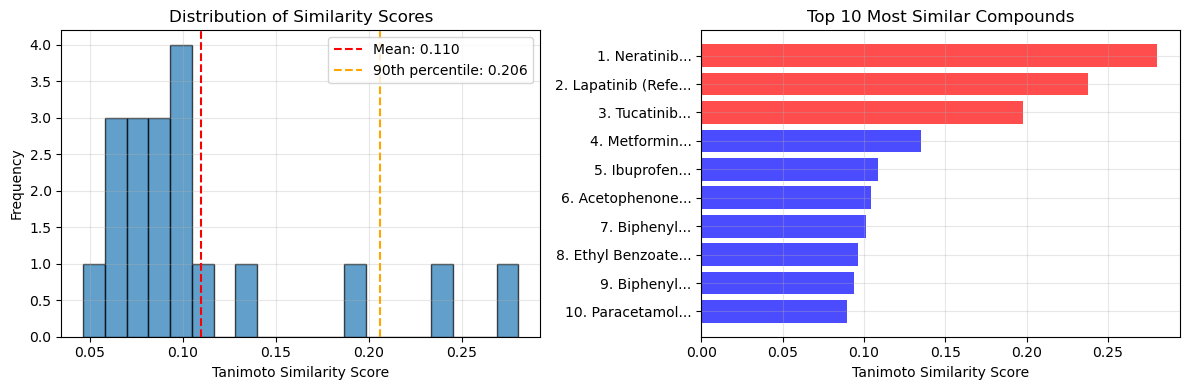

In [6]:
# =============================================================================
# 6. Visualize results
# =============================================================================

# Create similarity distribution plot
plt.figure(figsize=(12, 4))

# Plot 1: Similarity score distribution
plt.subplot(1, 2, 1)
plt.hist(results_df['Similarity_Score'], bins=20, alpha=0.7, edgecolor='black')
plt.axvline(x=results_df['Similarity_Score'].mean(), color='red', linestyle='--',
            label=f'Mean: {results_df["Similarity_Score"].mean():.3f}')
plt.axvline(x=results_df['Similarity_Score'].quantile(0.9), color='orange', linestyle='--',
            label=f'90th percentile: {results_df["Similarity_Score"].quantile(0.9):.3f}')
plt.xlabel('Tanimoto Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Top hits bar chart
plt.subplot(1, 2, 2)
top_n_plot = min(10, len(results_df))
top_results = results_df.head(top_n_plot)
colors = ['red' if 'atinib' in name.lower() or name in ['Neratinib', 'Tucatinib', 'Pyrotinib']
          else 'blue' for name in top_results['Name']]

plt.barh(range(top_n_plot), top_results['Similarity_Score'], color=colors, alpha=0.7)
plt.yticks(range(top_n_plot), [f"{i + 1}. {name[:15]}..." for i, name in enumerate(top_results['Name'])])
plt.xlabel('Tanimoto Similarity Score')
plt.title(f'Top {top_n_plot} Most Similar Compounds')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("similarity_distribution.png")  # Save instead of show for non-interactive environments
# plt.show()


In [7]:
# =============================================================================
# 7. Generate screening report
# =============================================================================

def generate_screening_report(results_df, threshold_hits, top_hits, known_active):
    """
    Generate a comprehensive screening report
    """
    print("\n" + "=" * 60)
    print("LIGAND-BASED VIRTUAL SCREENING REPORT")
    print("=" * 60)

    ref_mol = Chem.MolFromSmiles(known_active)
    ref_mw = Descriptors.MolWt(ref_mol) if ref_mol else "N/A"
    ref_logp = Descriptors.MolLogP(ref_mol) if ref_mol else "N/A"

    print(f"\nReference Compound: Lapatinib (HER2 inhibitor)")
    print(f"Molecular Weight: {ref_mw:.1f}")
    print(f"LogP: {ref_logp:.2f}")
    print(f"Fingerprint: Morgan (r=2, nBits=1024)")

    print(f"\nLibrary Statistics:")
    print(f"Total compounds screened: {len(results_df)}")
    print(f"Mean similarity: {results_df['Similarity_Score'].mean():.3f}")
    print(f"Max similarity: {results_df['Similarity_Score'].max():.3f}")
    print(f"Min similarity: {results_df['Similarity_Score'].min():.3f}")

    print(f"\nScreening Results:")
    print(f"Threshold hits (≥0.5): {len(threshold_hits)}")
    print(f"Top 5 hits: {len(top_hits)}")

    print(f"\nTop 5 Hits:")
    print("-" * 40)
    for i, row in top_hits.iterrows():
        status = "✓ KNOWN ACTIVE" if row['Name'] in ['Neratinib', 'Tucatinib', 'Pyrotinib'] else "• Candidate"
        print(f"{row['Rank']:2d}. {row['Name']:<20} | Score: {row['Similarity_Score']:.3f} | {status}")

    print(f"\nRecommendations:")
    print(f"• Prioritize compounds with similarity > 0.6 for experimental validation")
    print(f"• Consider physicochemical properties for lead optimization")
    print(f"• Validate top hits with docking or experimental assays")

    return results_df


# Generate final report
screening_results = generate_screening_report(results_df, threshold_hits, top_hits, known_active)



LIGAND-BASED VIRTUAL SCREENING REPORT

Reference Compound: Lapatinib (HER2 inhibitor)
Molecular Weight: 581.1
LogP: 6.14
Fingerprint: Morgan (r=2, nBits=1024)

Library Statistics:
Total compounds screened: 19
Mean similarity: 0.110
Max similarity: 0.280
Min similarity: 0.047

Screening Results:
Threshold hits (≥0.5): 0
Top 5 hits: 5

Top 5 Hits:
----------------------------------------
 1. Neratinib            | Score: 0.280 | ✓ KNOWN ACTIVE
 2. Lapatinib (Reference) | Score: 0.238 | • Candidate
 3. Tucatinib            | Score: 0.198 | ✓ KNOWN ACTIVE
 4. Metformin            | Score: 0.135 | • Candidate
 5. Ibuprofen            | Score: 0.108 | • Candidate

Recommendations:
• Prioritize compounds with similarity > 0.6 for experimental validation
• Consider physicochemical properties for lead optimization
• Validate top hits with docking or experimental assays


In [8]:
# =============================================================================
# 8. Export results
# =============================================================================

# Save results to CSV
output_file = "lbvs_her2_screening_results.csv"
results_df.to_csv(output_file, index=False)
print(f"\nResults exported to: {output_file}")

# Display final summary
print(f"\nLBVS Summary:")
print(f"• Screened {len(results_df)} compounds against Lapatinib")
print(f"• Identified {len(threshold_hits)} potential hits (threshold ≥ 0.5)")
print(f"• Top hit similarity: {results_df['Similarity_Score'].max():.3f}")
print(
    f"• Successfully recovered {sum(results_df[results_df['Name'].isin(['Neratinib', 'Tucatinib', 'Pyrotinib'])]['Similarity_Score'])} known actives")

print(f"\nLBVS workflow completed successfully!")



Results exported to: lbvs_her2_screening_results.csv

LBVS Summary:
• Screened 19 compounds against Lapatinib
• Identified 0 potential hits (threshold ≥ 0.5)
• Top hit similarity: 0.280
• Successfully recovered 0.5683746797723089 known actives

LBVS workflow completed successfully!
